In [10]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import random 
print("Setup works")


Setup works


In [3]:
DATASET_PATH = "/fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)"

TRAIN_DIR = os.path.join(DATASET_PATH, "train")
VALID_DIR = os.path.join(DATASET_PATH, "valid")

print("Train folder exists:", os.path.exists(TRAIN_DIR))
print("Valid folder exists:", os.path.exists(VALID_DIR))

print("Train path:", TRAIN_DIR)
print("Valid path:", VALID_DIR)

Train folder exists: True
Valid folder exists: True
Train path: /fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid path: /fs/ess/PAS2699/osc_summer_camp_2026/dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [4]:
all_classes = sorted(os.listdir(TRAIN_DIR))

print("Total number of classes:", len(all_classes))
print()

for i, cls in enumerate(all_classes):
    print(f"{i+1:>2}. {cls}")

Total number of classes: 38

 1. Apple___Apple_scab
 2. Apple___Black_rot
 3. Apple___Cedar_apple_rust
 4. Apple___healthy
 5. Blueberry___healthy
 6. Cherry_(including_sour)___Powdery_mildew
 7. Cherry_(including_sour)___healthy
 8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
 9. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tom

In [5]:
class_counts = {}

for cls in all_classes:
    class_folder = os.path.join(TRAIN_DIR, cls)
    num_images = len(os.listdir(class_folder))
    class_counts[cls] = num_images

total_train = sum(class_counts.values())

print("Total training images:", total_train)
print()

top10 = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)[:10]

print("Top 10 classes by image count:")
for cls, count in top10:
    print(f"{cls:<45} {count:>5} images")

Total training images: 70295

Top 10 classes by image count:
Soybean___healthy                              2022 images
Apple___Apple_scab                             2016 images
Orange___Haunglongbing_(Citrus_greening)       2010 images
Apple___healthy                                2008 images
Pepper,_bell___healthy                         1988 images
Apple___Black_rot                              1987 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus         1961 images
Potato___Early_blight                          1939 images
Potato___Late_blight                           1939 images
Tomato___healthy                               1926 images


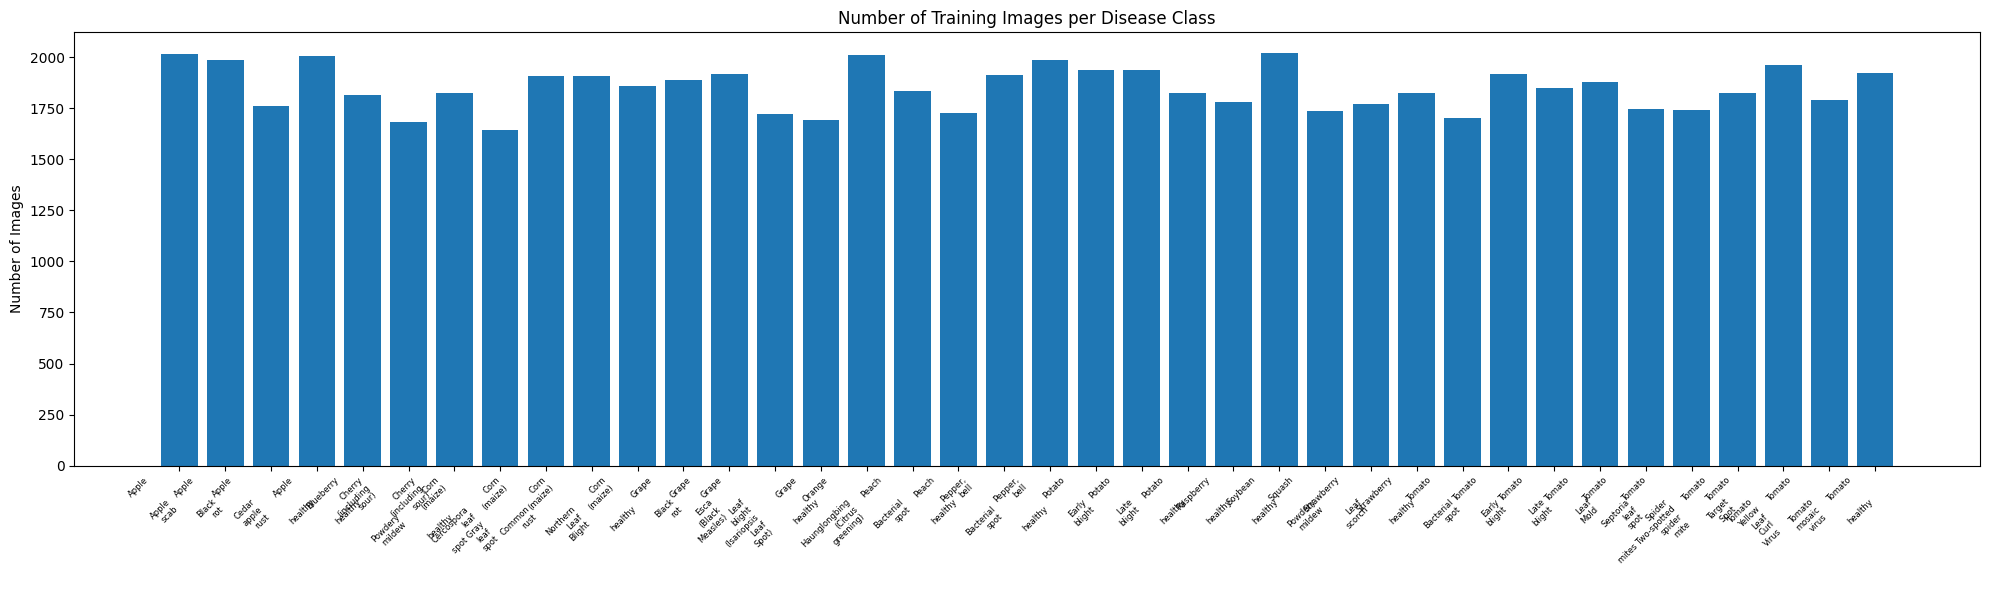

In [6]:
short_labels = [c.replace("_", "\n") for c in class_counts.keys()]
counts = list(class_counts.values())

plt.figure(figsize=(20, 6))
plt.bar(range(len(counts)), counts)
plt.xticks(range(len(short_labels)), short_labels, fontsize=6, rotation=45, ha="right")
plt.ylabel("Number of Images")
plt.title("Number of Training Images per Disease Class")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

In [11]:
def show_random_images(class_name, num_images=4):
    folder = os.path.join(TRAIN_DIR, class_name)

    if not os.path.exists(folder):
        print("Class folder does not exist:", folder)
        return

    all_files = os.listdir(folder)
    chosen = random.sample(all_files, min(num_images, len(all_files)))

    fig, axes = plt.subplots(1, len(chosen), figsize=(14, 4))
    fig.suptitle(f"Class: {class_name}", fontsize=13, fontweight="bold")

    if len(chosen) == 1:
        axes = [axes]

    for ax, filename in zip(axes, chosen):
        img_path = os.path.join(folder, filename)
        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"{img.shape[1]}x{img.shape[0]}", fontsize=9)

    plt.tight_layout()
    plt.show()

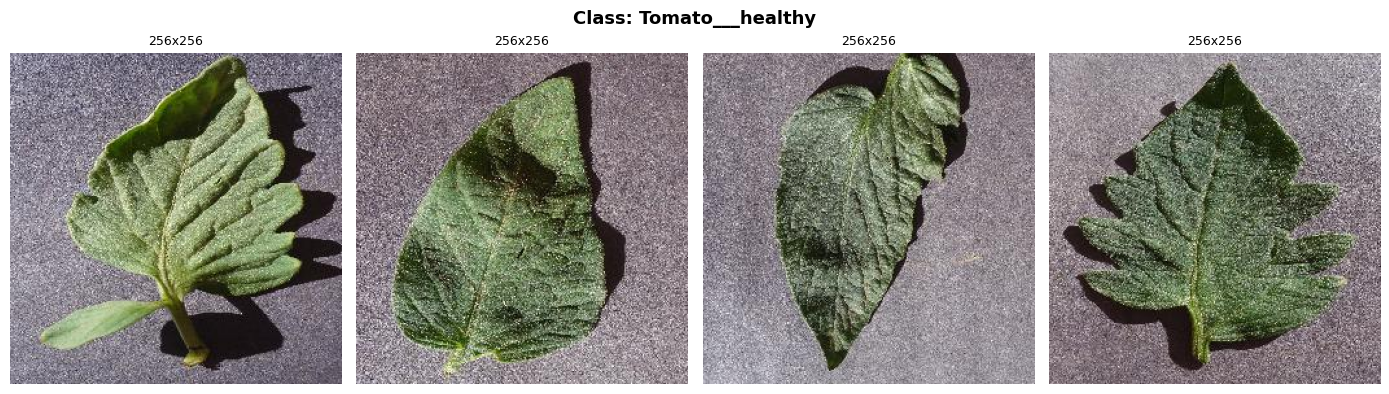

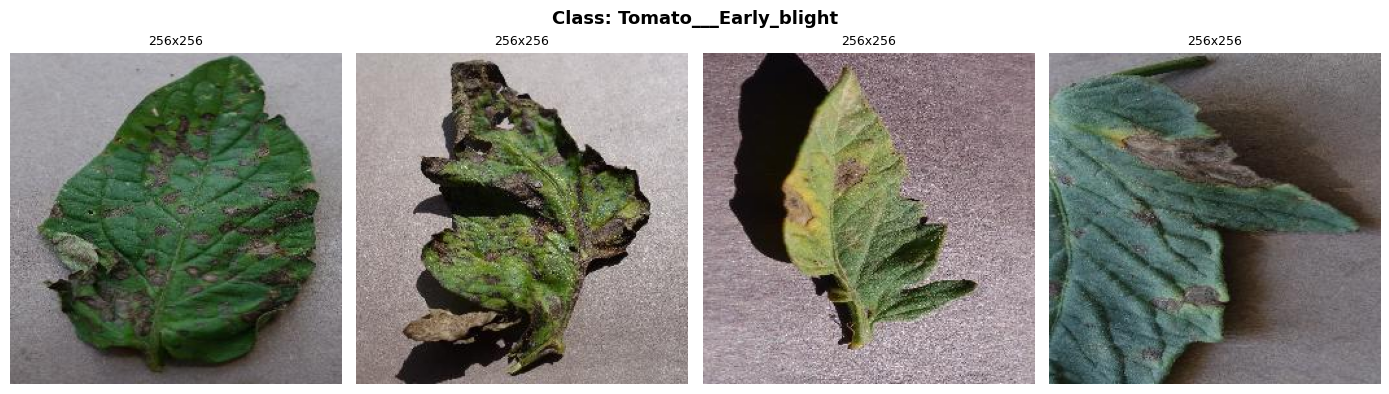

In [12]:
show_random_images("Tomato___healthy")
show_random_images("Tomato___Early_blight")

In [13]:
def compare_healthy_vs_diseased(healthy_class, diseased_class):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle("Healthy vs Diseased — Can you spot the difference?", fontsize=13)

    for ax, cls, label in zip(
        axes,
        [healthy_class, diseased_class],
        ["Healthy", "Diseased"]
    ):
        folder = os.path.join(TRAIN_DIR, cls)

        if not os.path.exists(folder):
            print("Missing class:", cls)
            continue

        filename = random.choice(os.listdir(folder))
        img = mpimg.imread(os.path.join(folder, filename))

        ax.imshow(img)
        ax.set_title(label + "\n" + cls, fontsize=10)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

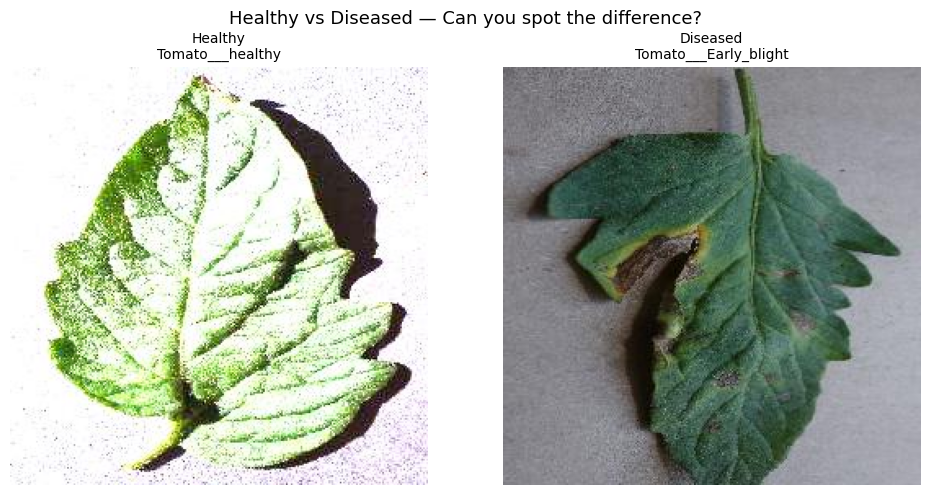

In [14]:
compare_healthy_vs_diseased(
    healthy_class="Tomato___healthy",
    diseased_class="Tomato___Early_blight"
)

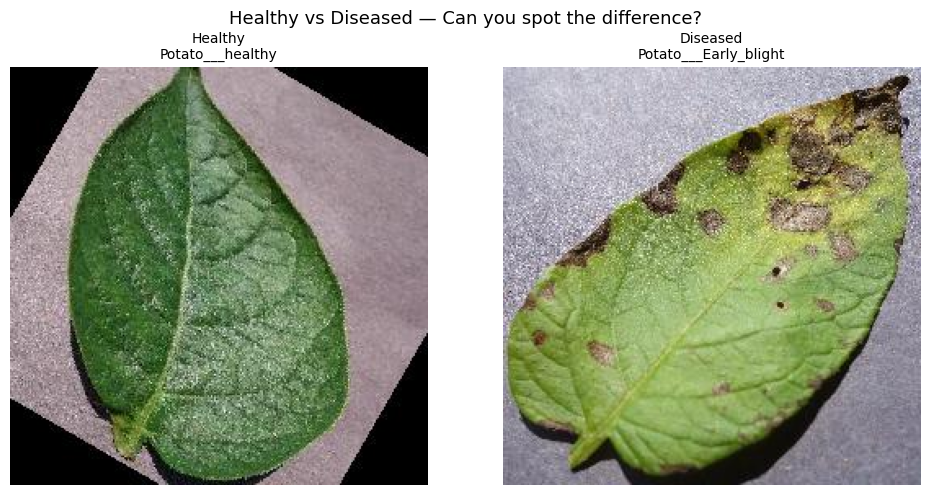

In [15]:
compare_healthy_vs_diseased(
    healthy_class="Potato___healthy",
    diseased_class="Potato___Early_blight"
)

In [22]:
sample_folder = os.path.join(TRAIN_DIR, "Tomato___healthy")
sample_file = os.listdir(sample_folder)[0]
sample_img = mpimg.imread(os.path.join(sample_folder, sample_file))

print("Image shape:", sample_img.shape)
print("Height:", sample_img.shape[0])
print("Width:", sample_img.shape[1])
print("Color channels:", sample_img.shape[2])

print("\nTop-left 4x4 pixel values from Red channel:")
print(sample_img[:4, :4, 2]) # 0 represents channel code (0-red, 1-green, 2-blue)

Image shape: (256, 256, 3)
Height: 256
Width: 256
Color channels: 3

Top-left 4x4 pixel values from Red channel:
[[177 211 185 166]
 [151 164 218 172]
 [184 172 138 210]
 [157 166 136 105]]


In [23]:
smallest_class = min(class_counts.items(), key=lambda x: x[1])
largest_class = max(class_counts.items(), key=lambda x: x[1])

print("Smallest class:", smallest_class[0], "-", smallest_class[1], "images")
print("Largest class:", largest_class[0], "-", largest_class[1], "images")

Smallest class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot - 1642 images
Largest class: Soybean___healthy - 2022 images


In [24]:
plant_name = "Apple"

matching_classes = [cls for cls in all_classes if plant_name in cls]

print(f"Classes containing '{plant_name}':")
for cls in matching_classes:
    print(cls)

Classes containing 'Apple':
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
